# Quantification of Celltype/Stage mapping

In [1]:
# Load packages
suppressPackageStartupMessages({
    library(ggplot2)
    library(biomaRt)
    library(BiocParallel)
    library(Matrix)
    library(matrixStats)
    library(scater)
    library(reshape2)
    library(knitr)
    library(scran)
    library(batchelor)
    library(reticulate)
    library(SingleCellExperiment)
    library(data.table)
    library(dplyr)
    library(gridExtra)
})
    ncores = 4
    mcparam = MulticoreParam(workers = ncores)
    register(mcparam)
    BPPARAM = SerialParam()

options(repr.plot.width=15, repr.plot.height=8)

### I/O

In [2]:
main = "/rds/project/rds-SDzz0CATGms/users/bt392/01_Eomes_RNA/"
mapping_dir = paste0(main, '07_atlas_mapping/')
out_dir = paste0(main, '08_mapping_quantification/')
dir.create(out_dir, showWarnings = FALSE)

source(paste0(main, "mapping_functions.R"))

In [3]:
umap_theme =  theme(text = element_text(size = 30),
                axis.text.y   = element_blank(),
                axis.text.x   = element_blank(),
                axis.title.y  = element_blank(),
                axis.title.x  = element_blank(),
                axis.ticks = element_blank(),
                legend.position = "none",
                panel.background = element_blank(),
                panel.grid.major = element_blank(), 
                panel.grid.minor = element_blank(),
                panel.border = element_rect(colour = "black", fill=NA, size=1))

### Load data

In [3]:
meta = read.csv(paste0(mapping_dir, 'meta_complete.csv'))

### Plot mapped celltypes/stages on the chimera-only UMAP

In [21]:
meta$umap_1 = as.numeric(meta$umap_1)
meta$umap_2 = as.numeric(meta$umap_2)

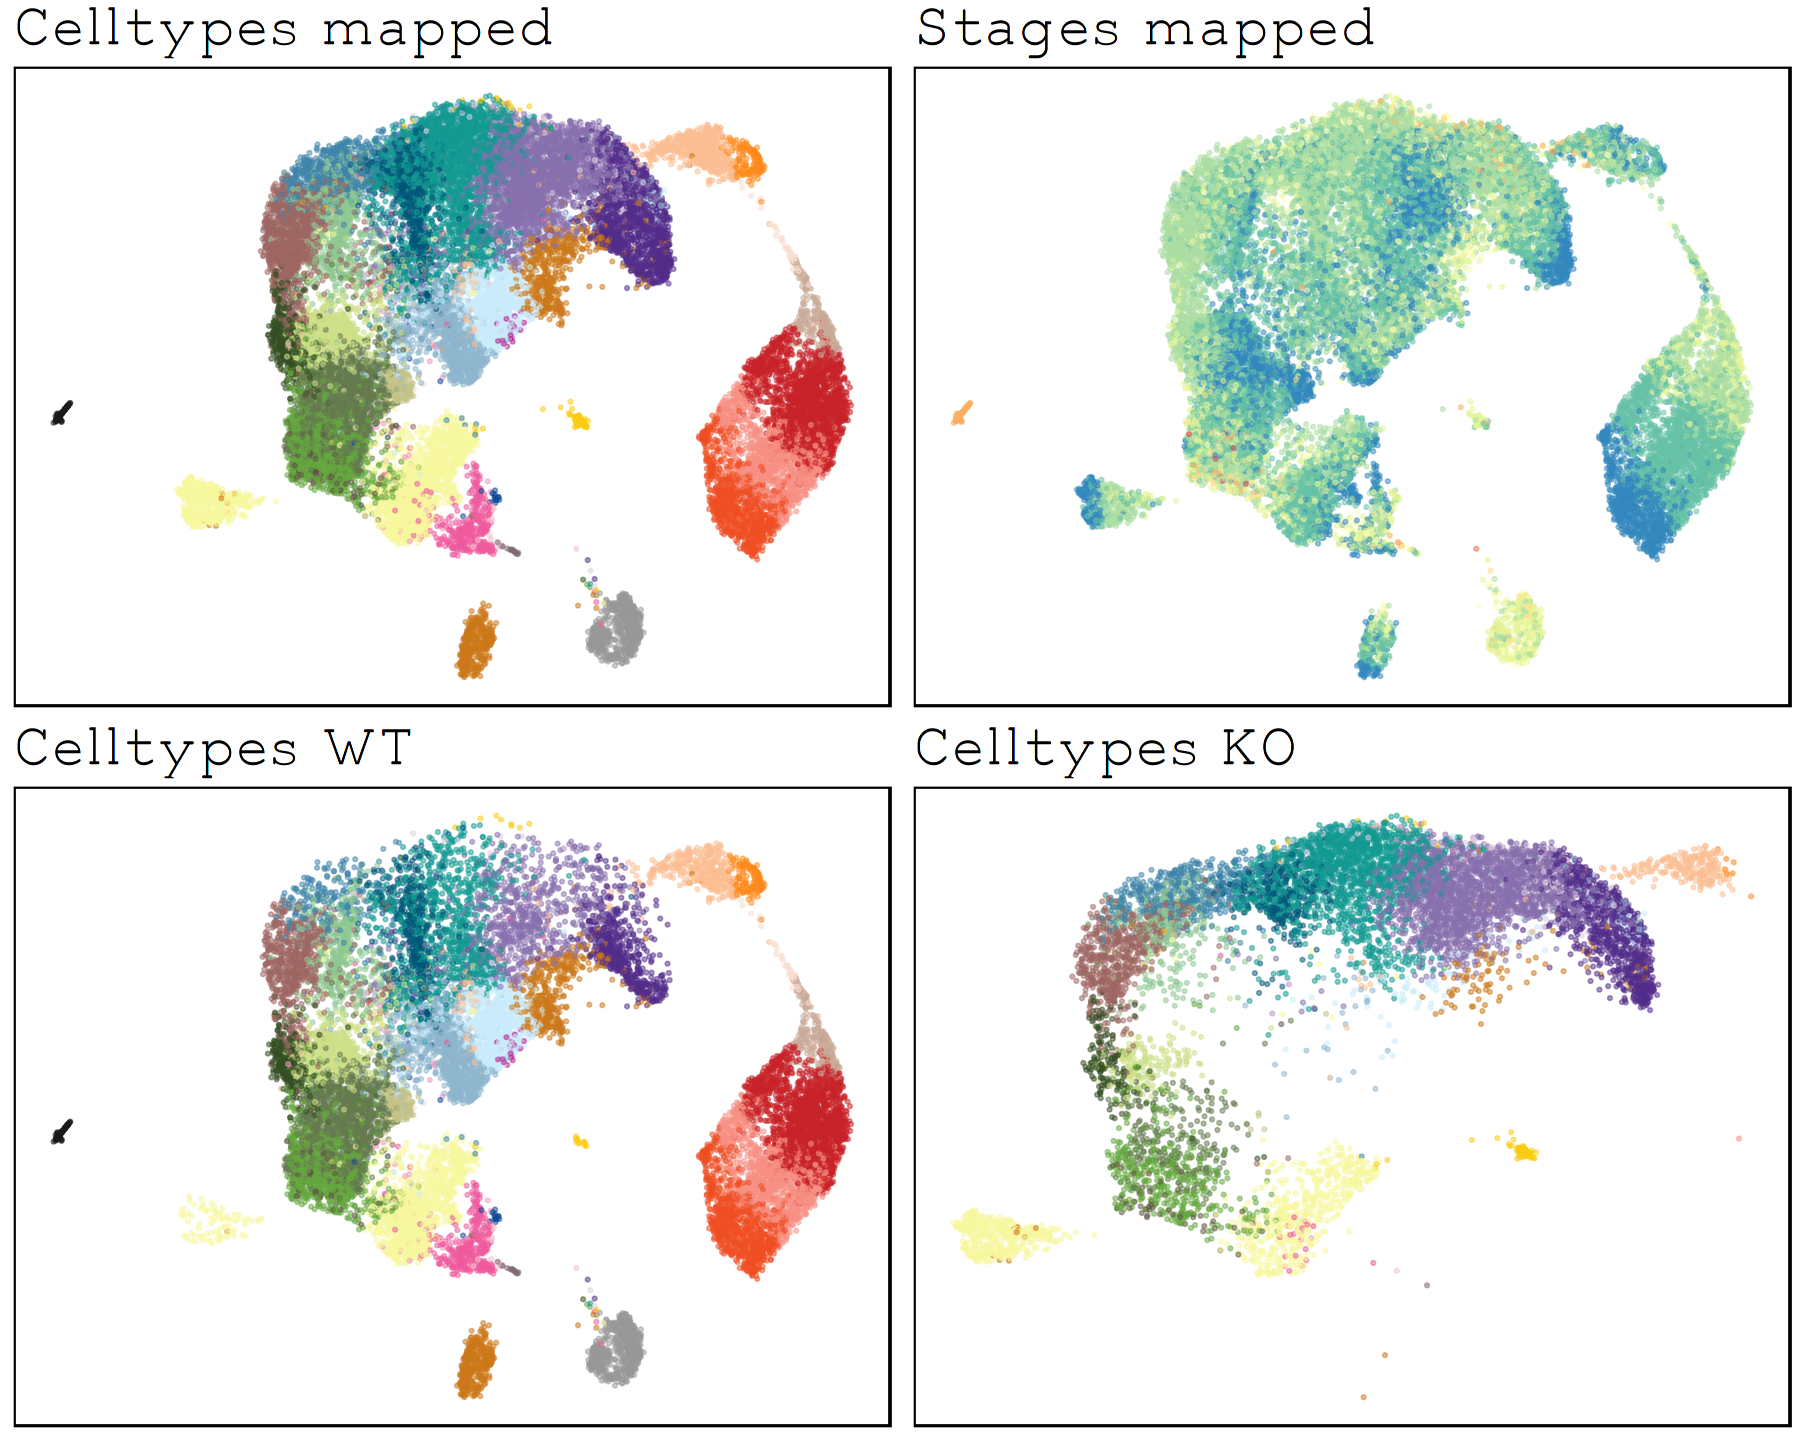

In [5]:
p1 = ggplot(meta, aes(umap_1, umap_2, col=celltype.mapped)) + 
    geom_point(size = 0.7, alpha = 0.5) + 
    scale_colour_manual(values = celltype_colours, name = "celltype") +
    ggtitle('Celltypes mapped') +
    umap_theme

p2 = ggplot(meta, aes(umap_1, umap_2, col=stage.mapped)) + 
    geom_point(size = 0.7, alpha = 0.5) + 
    scale_colour_manual(values = stage_colours, name = "Stage") +
    ggtitle('Stages mapped') +
    umap_theme

p3 = ggplot(meta[meta$tdTom=='negative',], aes(umap_1, umap_2, col=celltype.mapped)) + 
    geom_point(size = 0.7, alpha = 0.5) + 
    scale_colour_manual(values = celltype_colours, name = "celltype") +
    ggtitle('Celltypes WT') +
    umap_theme

p4 = ggplot(meta[meta$tdTom=='positive',], aes(umap_1, umap_2, col=celltype.mapped)) + 
    geom_point(size = 0.7, alpha = 0.5) + 
    scale_colour_manual(values = celltype_colours, name = "celltype") +
    ggtitle('Celltypes KO') +
    umap_theme

options(repr.plot.width=15, repr.plot.height=12)
grid.arrange(p1, p2, p3, p4, ncol = 2)
options(repr.plot.width=15, repr.plot.height=8)

# Cell-types seemed to be mapped allright, both when mapping on the atlas and when only looking at the chimera data

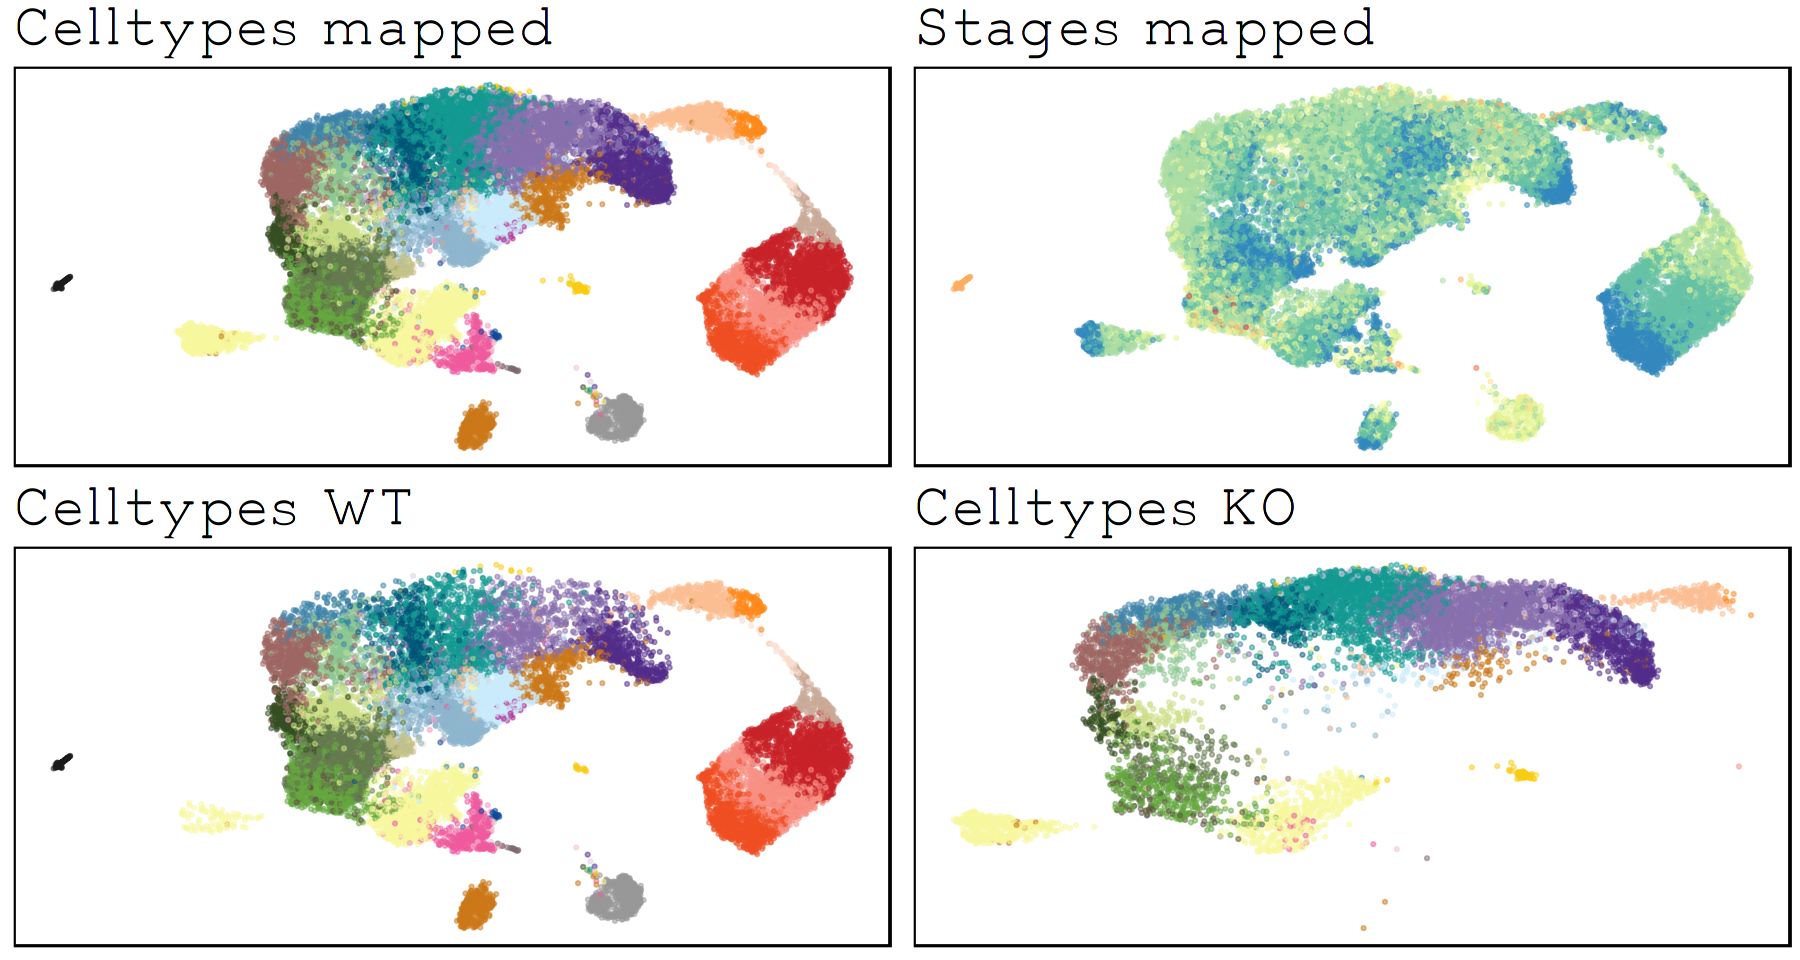

In [6]:
ggsave(paste0(out_dir, 'UMAPs_chim_only.png'), 
       plot = grid.arrange(p1, p2, p3, p4, ncol=2), 
       device = 'png',
       width = 12,
       height = 8,
       dpi = 300)

### Quantifications

In [4]:
pools = data.frame('sample' = unique(meta$sample), 'sample_name' = unique(meta$Sample_name))
pools[order(pools$sample),]

,sample,sample_name
,<int>,<chr>
5,1,MLT_D6 Tom+
7,2,MLT_D6 Tom-
1,3,MLT_G9 Tom+
3,4,MLT_G9 Tom-
4,5,MLT_A8+
6,6,MLT_A8-
8,7,MLT_C7+
2,8,MLT_C7-


In [5]:
embryo_pools = data.frame('sample' = 1:8, embryo_pool = c(1,1,2,2,3,3,4,4))
meta = merge(meta, embryo_pools, by='sample')

In [6]:
quant_theme = theme(text = element_text(size = 30, color='black'),
                    axis.text.x = element_text(angle = -40, hjust = 0, size = 14, color='black'),
                    legend.position = "none",
                    panel.background = element_blank(),
                    panel.grid.major = element_line(colour='grey93'), 
                    panel.grid.minor = element_line(colour='grey98'),
                    axis.title.x = element_blank(),
                    panel.border = element_rect(colour = "black", fill=NA, size=1),
                   strip.background = element_rect(fill = "white", color = "black", size = 1))


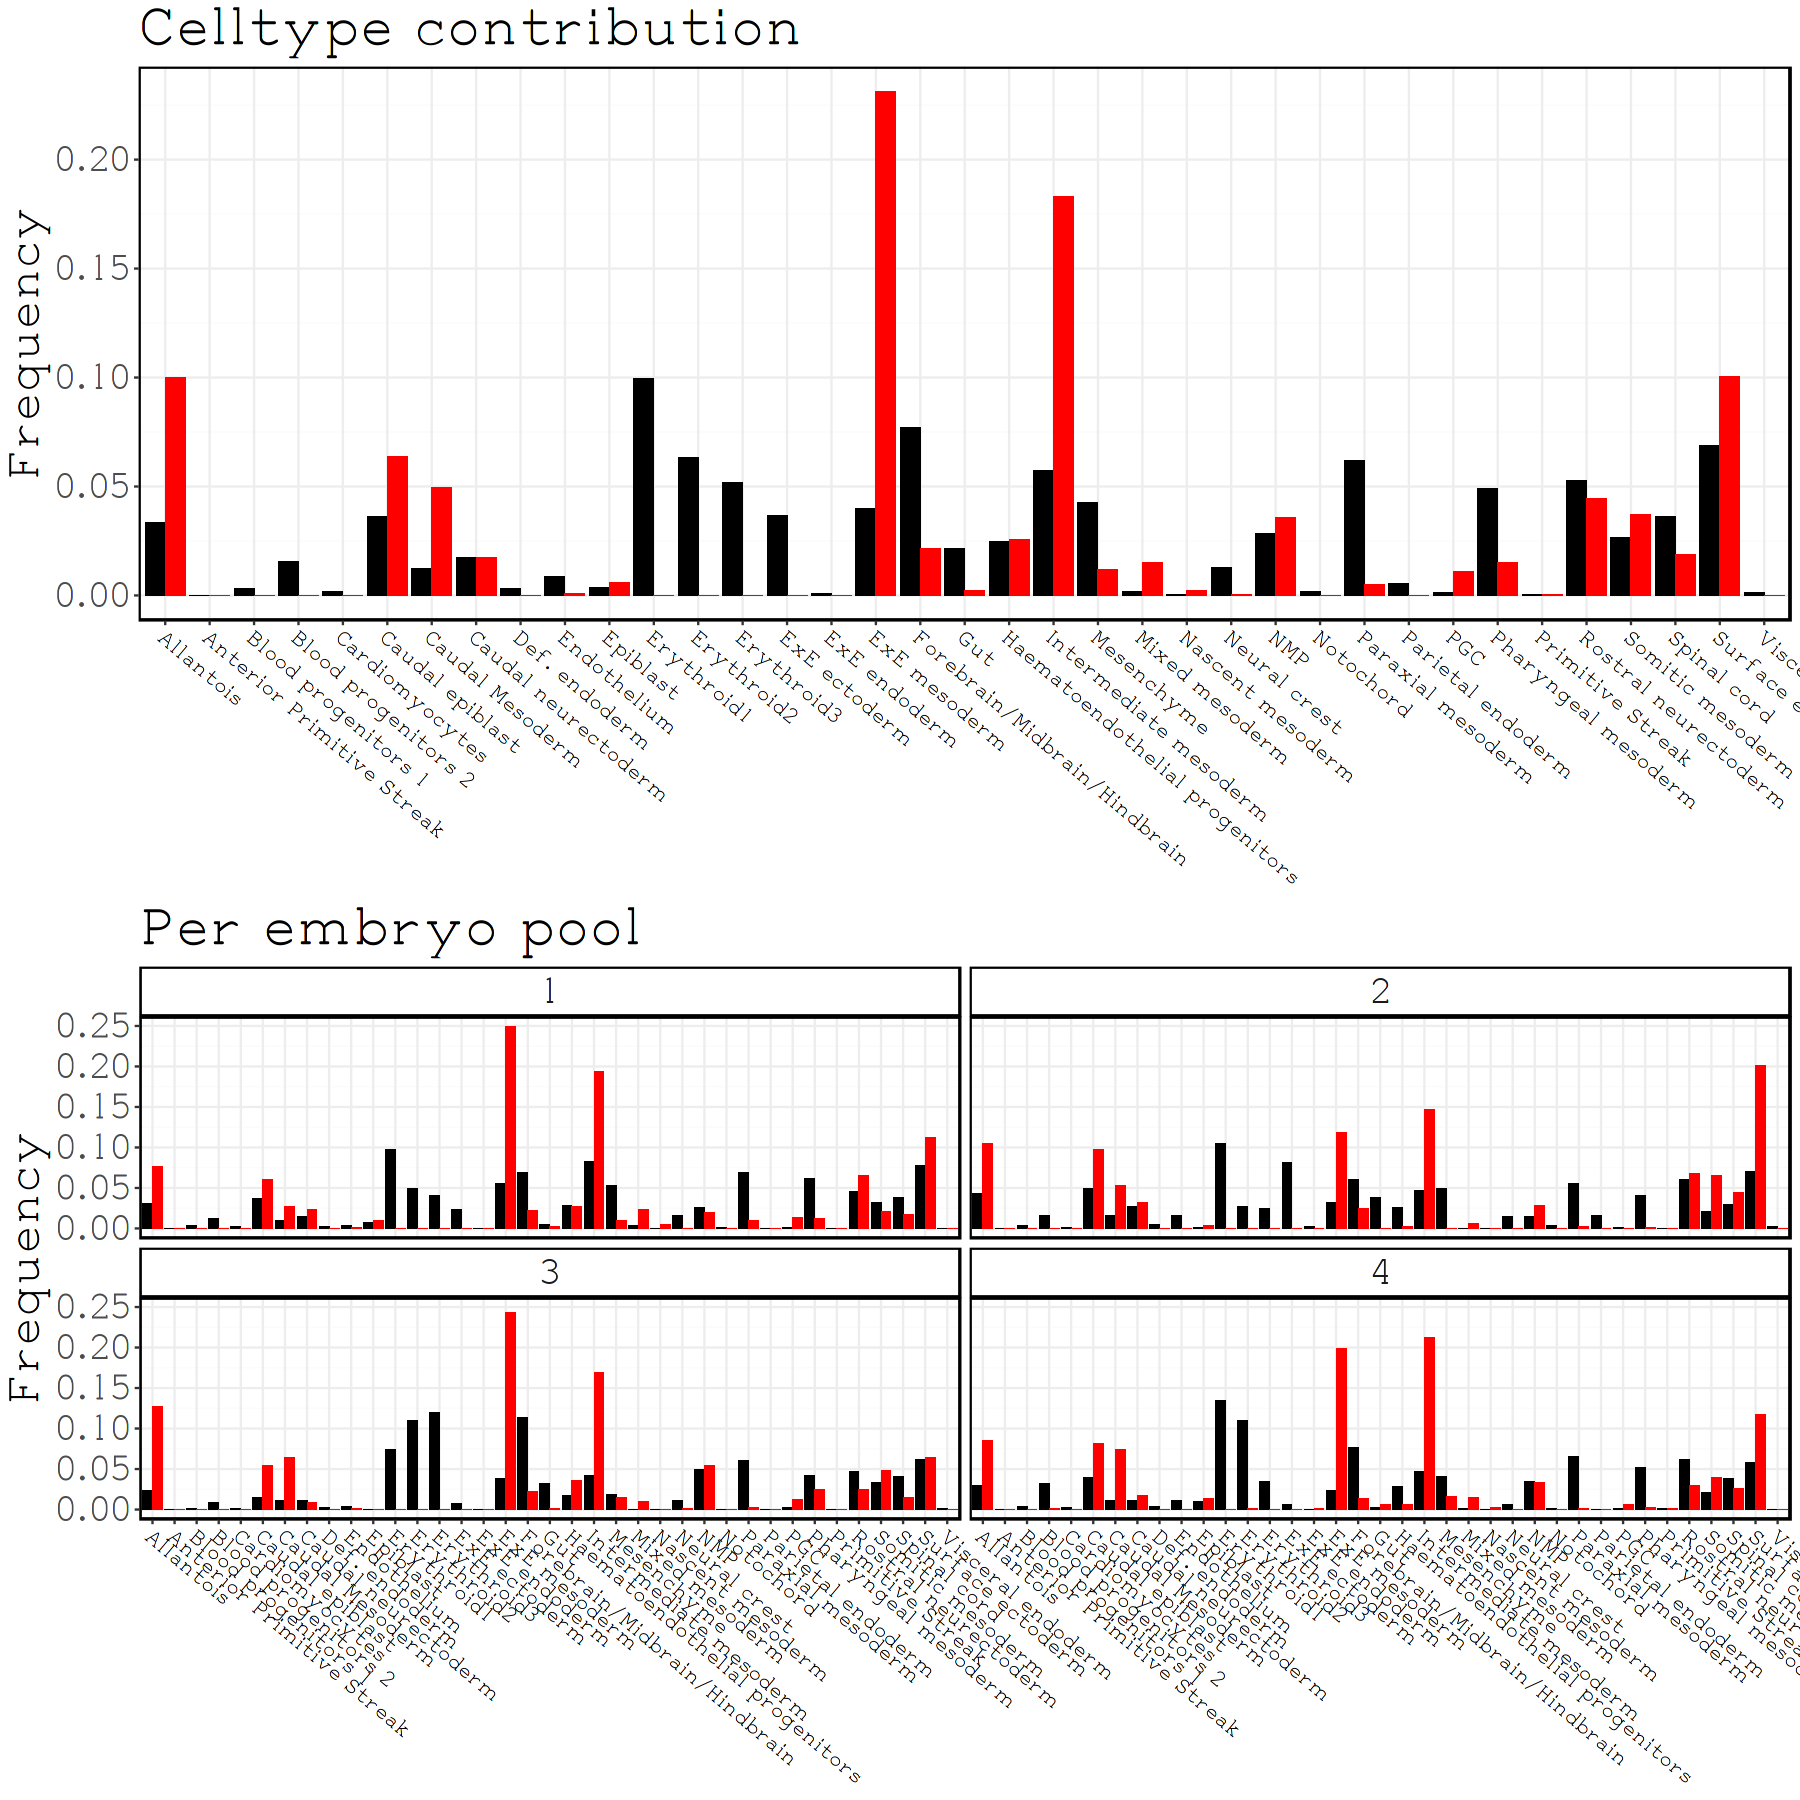

In [10]:
pdf1 = table(meta$celltype.mapped, meta$tdTom)
pdf1 = as.data.frame(sweep(pdf1, 2, colSums(pdf1), "/"))

p1 = ggplot(data = pdf1, mapping = aes(x = Var1, y = Freq, fill = Var2)) +
        geom_bar(stat = "identity", position = "dodge") +
        scale_fill_manual(values = c('positive' = 'red', 'negative' = 'black')) +
        scale_x_discrete(breaks = unique(meta$celltype.mapped)[order(unique(meta$celltype.mapped))]) +
        ggtitle('Celltype contribution') +
        ylab('Frequency') + 
        quant_theme 

pdf1 = table(meta$celltype.mapped, meta$tdTom, meta$embryo_pool)
pdf1 = as.data.frame(sweep(pdf1, 2:3, colSums(pdf1), "/"))

p2 = ggplot(data = pdf1, mapping = aes(x = Var1, y = Freq, fill = Var2)) +
        geom_bar(stat = "identity", position = "dodge") +
        scale_fill_manual(values = c('positive' = 'red', 'negative' = 'black')) +
        scale_x_discrete(breaks = unique(meta$celltype.mapped)[order(unique(meta$celltype.mapped))]) +
        ggtitle('Per embryo pool') + 
        ylab('Frequency') + 
        facet_wrap(~Var3) +
        quant_theme 
options(repr.plot.width=15, repr.plot.height=15)
grid.arrange(p1, p2, ncol = 1)
options(repr.plot.width=15, repr.plot.height=8)

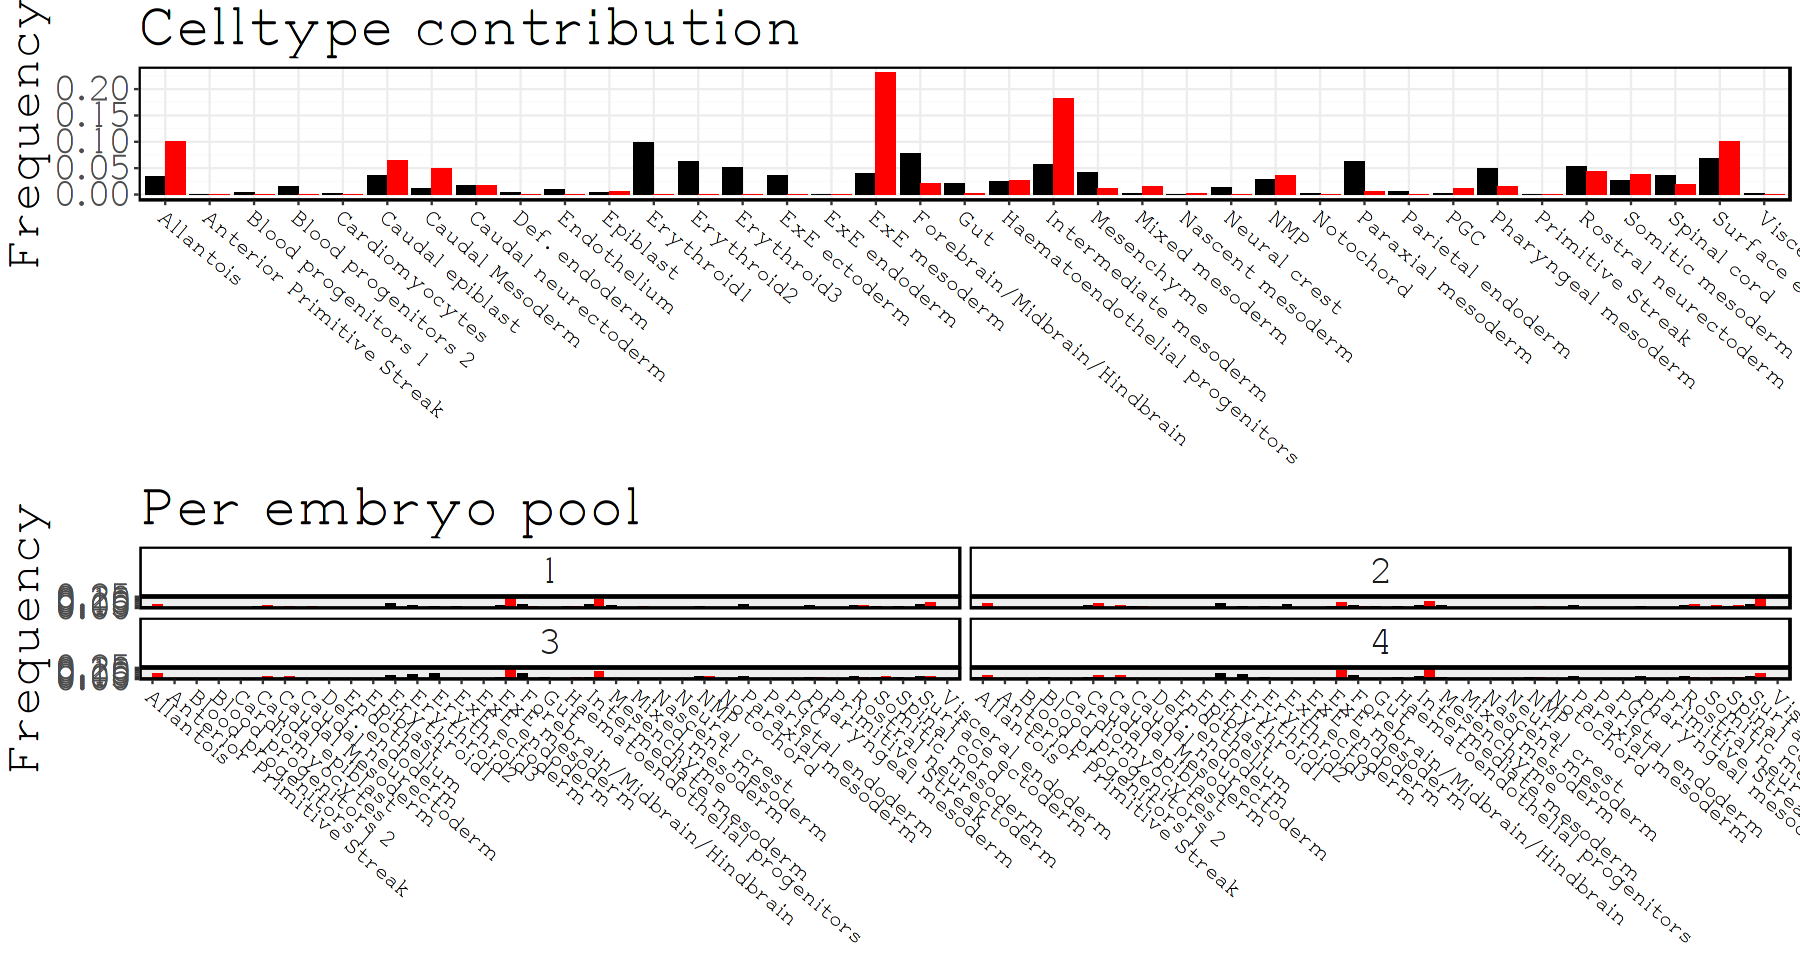

In [11]:
ggsave(paste0(out_dir, 'celltype_distributions.pdf'), 
       plot = grid.arrange(p1, p2, ncol = 1), 
       device = 'pdf',
       width = 15,
       height = 17)

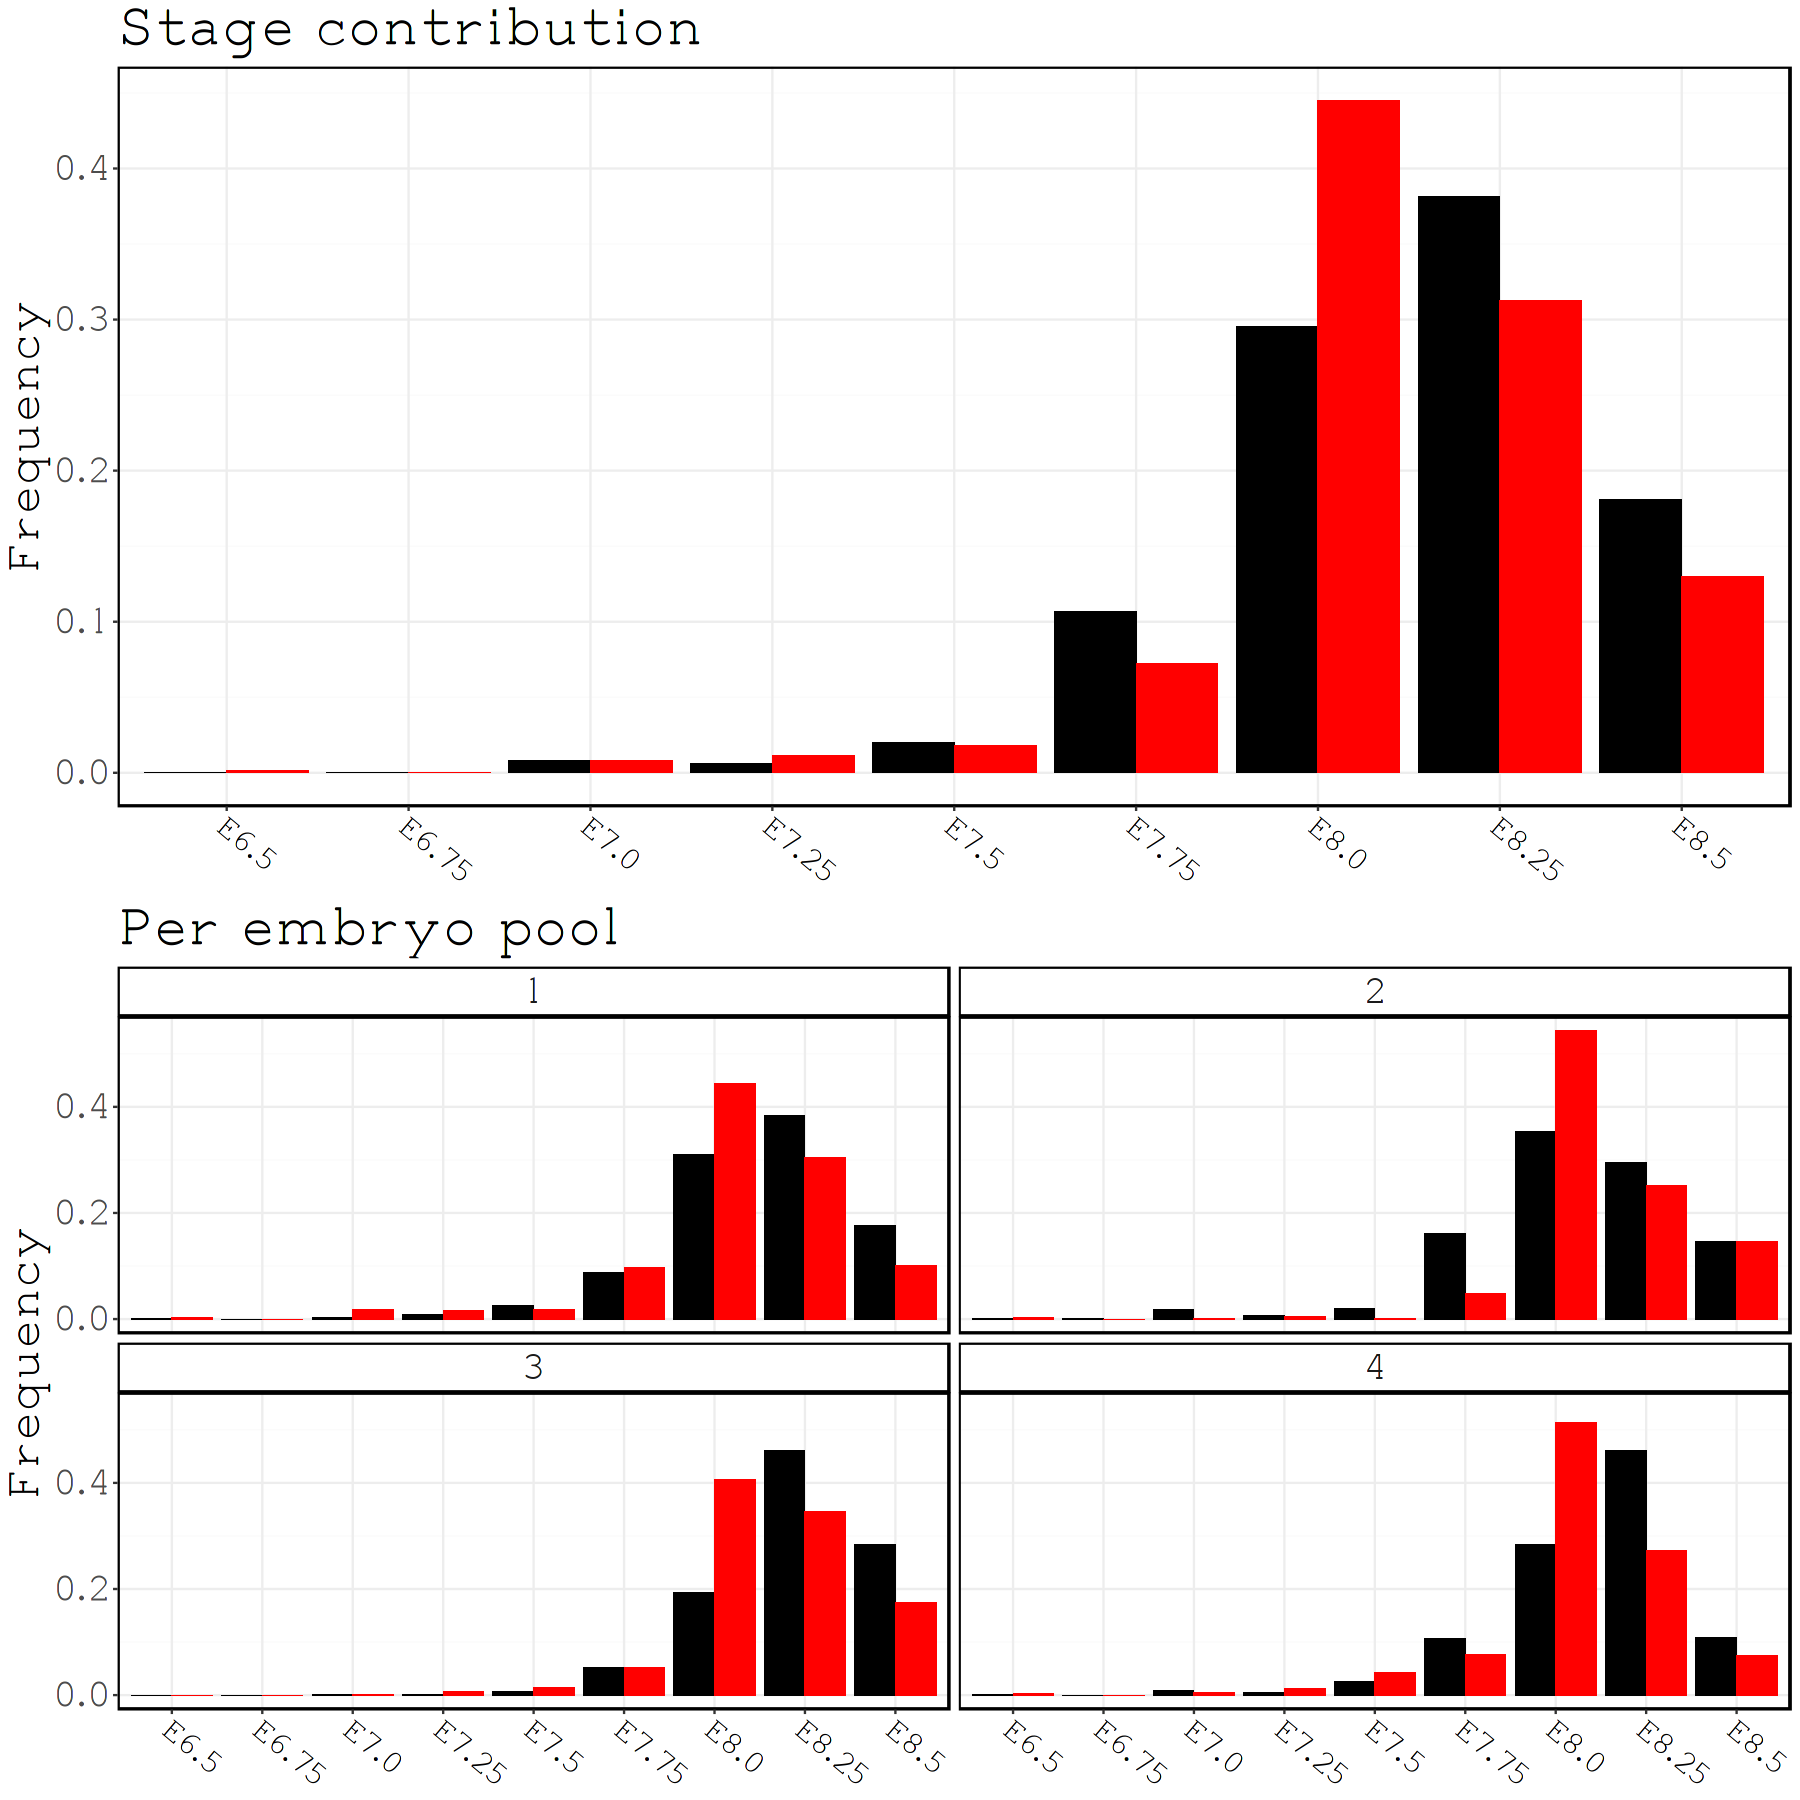

In [7]:
pdf1 = table(meta$stage.mapped, meta$tdTom)
pdf1 = as.data.frame(sweep(pdf1, 2, colSums(pdf1), "/"))

p1 = ggplot(data = pdf1, mapping = aes(x = Var1, y = Freq, fill = Var2)) +
        geom_bar(stat = "identity", position = "dodge") +
        scale_fill_manual(values = c('positive' = 'red', 'negative' = 'black')) +
        scale_x_discrete(breaks = unique(meta$stage.mapped)[order(unique(meta$stage.mapped))]) +
        ggtitle('Stage contribution') +
        ylab('Frequency') + 
        quant_theme + theme(axis.text.x = element_text(angle = -40, hjust = 0, size = 20, color='black'))

pdf1 = table(meta$stage.mapped, meta$tdTom, meta$embryo_pool)
pdf1 = as.data.frame(sweep(pdf1, 2:3, colSums(pdf1), "/"))

p2 = ggplot(data = pdf1, mapping = aes(x = Var1, y = Freq, fill = Var2)) +
        geom_bar(stat = "identity", position = "dodge") +
        scale_fill_manual(values = c('positive' = 'red', 'negative' = 'black')) +
        scale_x_discrete(breaks = unique(meta$stage.mapped)[order(unique(meta$stage.mapped))]) +
        ggtitle('Per embryo pool') + 
        ylab('Frequency') + 
        facet_wrap(~Var3) +
        quant_theme + theme(axis.text.x = element_text(angle = -40, hjust = 0, size = 20, color='black'))

options(repr.plot.width=15, repr.plot.height=15)
grid.arrange(p1, p2, ncol = 1)
options(repr.plot.width=15, repr.plot.height=8)

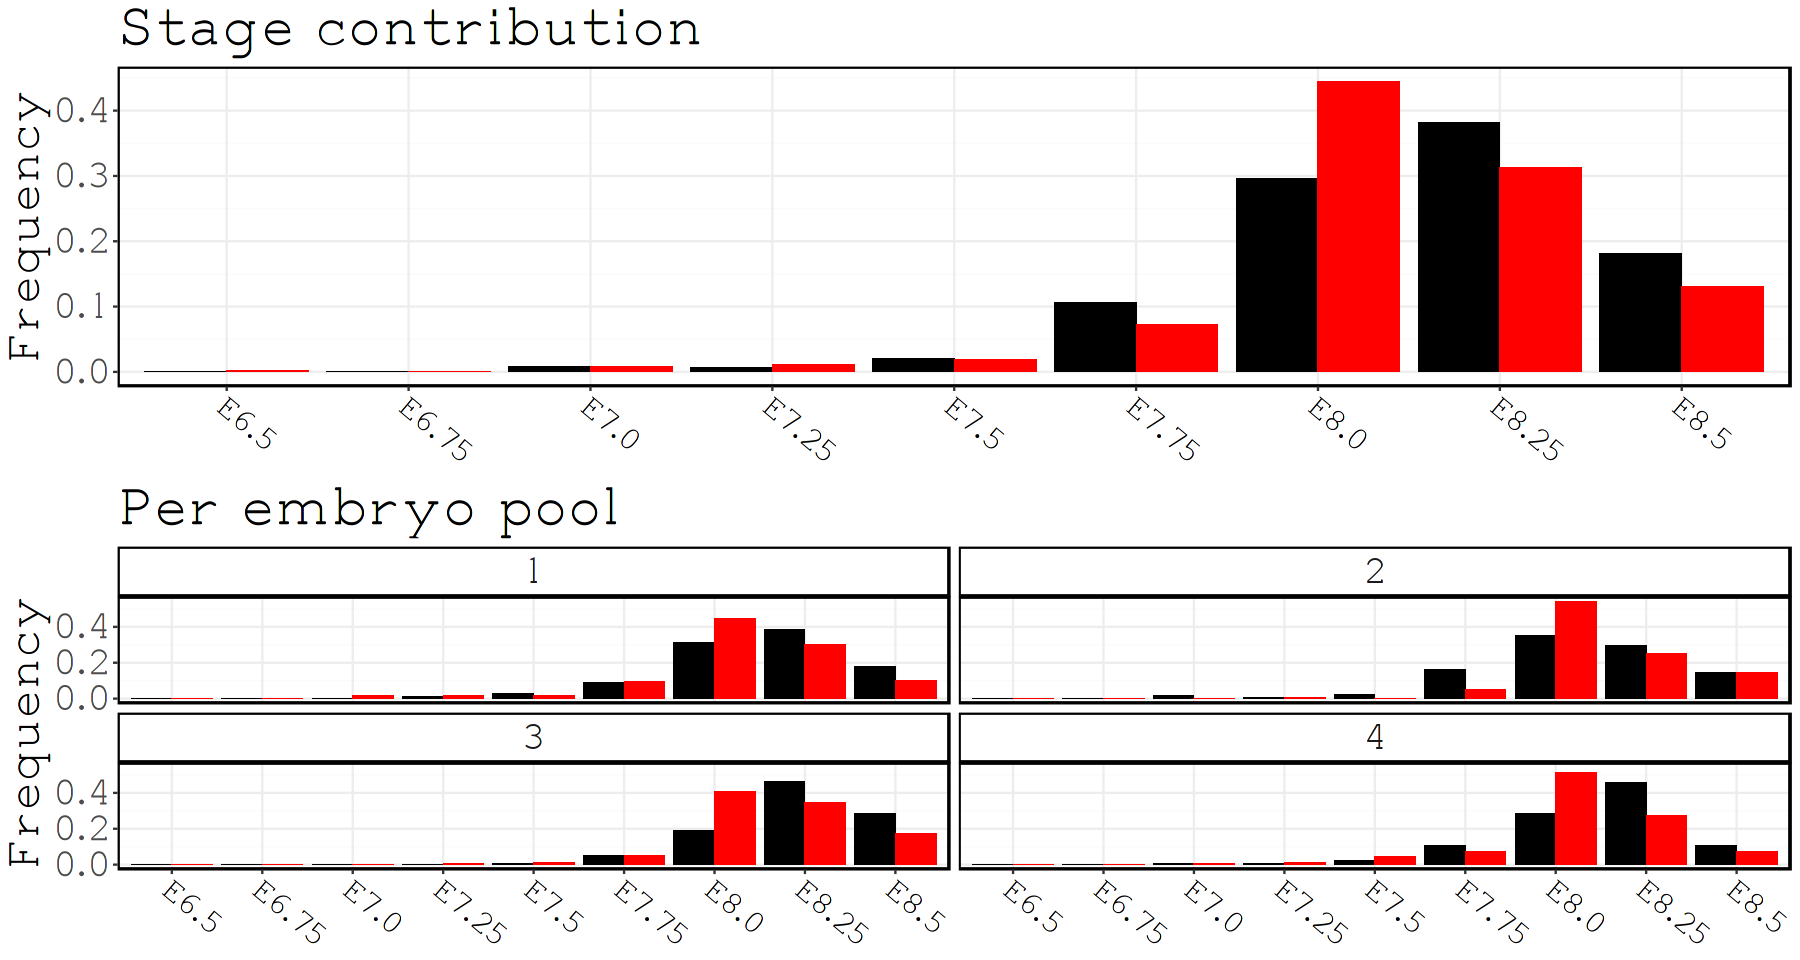

In [8]:
ggsave(paste0(out_dir, 'stage_distributions.pdf'), 
       plot = grid.arrange(p1, p2, ncol = 1), 
       device = 'pdf',
       width = 15,
       height = 17)

Warning message:
“Removed 72 rows containing missing values (geom_bar).”


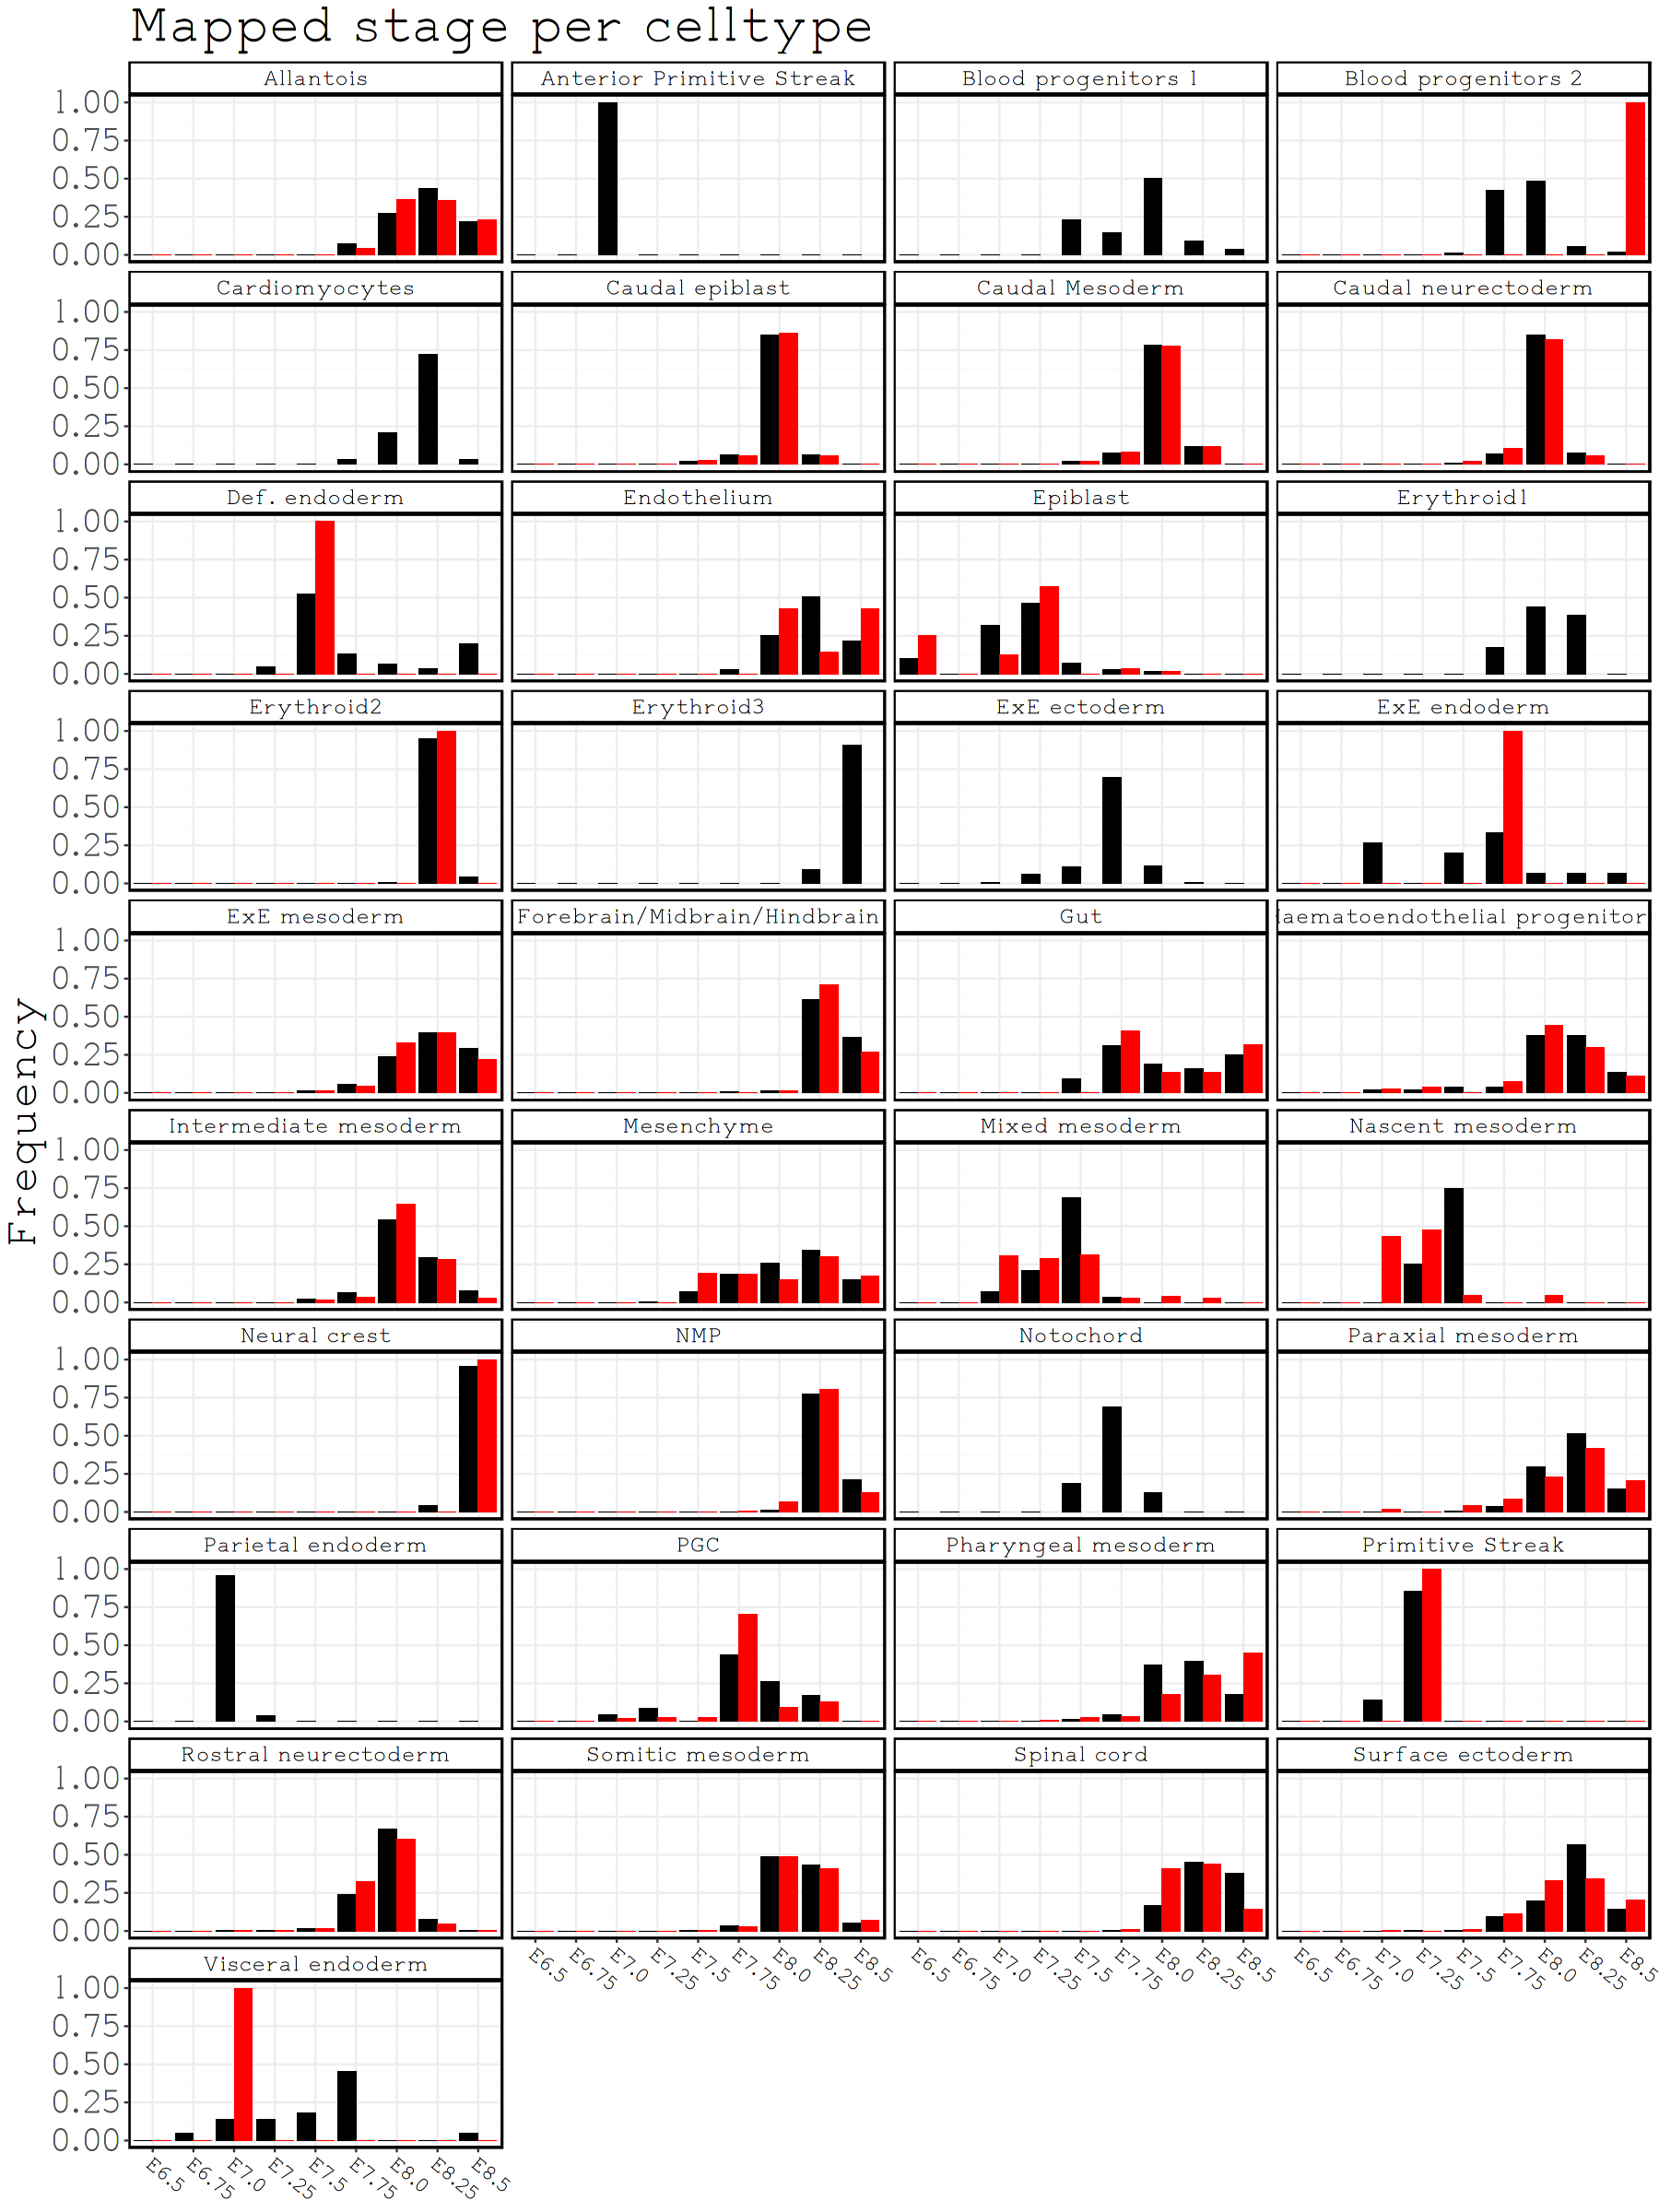

In [14]:
pdf1 = table(meta$stage.mapped, meta$tdTom, meta$celltype.mapped)
pdf1 = as.data.frame(sweep(pdf1, 2:3, colSums(pdf1), "/"))

p1 = ggplot(data = pdf1, mapping = aes(x = Var1, y = Freq, fill = Var2)) +
        geom_bar(stat = "identity", position = "dodge") +
        scale_fill_manual(values = c('positive' = 'red', 'negative' = 'black')) +
        scale_x_discrete(breaks = unique(meta$stage.mapped)[order(unique(meta$stage.mapped))]) +
        ggtitle('Mapped stage per celltype') + 
        ylab('Frequency') + 
        facet_wrap(~Var3, ncol = 4) +
        quant_theme + theme(strip.text = element_text(size = 15, color='black'))
options(repr.plot.width=15, repr.plot.height=20)
p1

In [15]:
ggsave(paste0(out_dir, 'stage_per_celltype.pdf'), 
       plot = p1, 
       device = 'pdf',
       width = 15,
       height = 20)

Warning message:
“Removed 72 rows containing missing values (geom_bar).”


In [16]:
sessionInfo()

R version 4.0.3 (2020-10-10)
Platform: x86_64-pc-linux-gnu (64-bit)
Running under: Manjaro Linux

Matrix products: default
BLAS:   /usr/local/lib64/R/lib/libRblas.so
LAPACK: /usr/local/lib64/R/lib/libRlapack.so

locale:
 [1] LC_CTYPE=en_GB.UTF-8       LC_NUMERIC=C              
 [3] LC_TIME=en_GB.UTF-8        LC_COLLATE=en_GB.UTF-8    
 [5] LC_MONETARY=en_GB.UTF-8    LC_MESSAGES=en_GB.UTF-8   
 [7] LC_PAPER=en_GB.UTF-8       LC_NAME=C                 
 [9] LC_ADDRESS=C               LC_TELEPHONE=C            
[11] LC_MEASUREMENT=en_GB.UTF-8 LC_IDENTIFICATION=C       

attached base packages:
[1] parallel  stats4    stats     graphics  grDevices utils     datasets 
[8] methods   base     

other attached packages:
 [1] cowplot_1.1.1               gridExtra_2.3              
 [3] dplyr_1.0.7.9000            data.table_1.14.2          
 [5] reticulate_1.18             batchelor_1.6.2            
 [7] scran_1.18.1                knitr_1.30                 
 [9] reshape2_1.4.4              